# CartPole pipeline

This notebook uses only relative paths from `Cartpole/notebooks/`.
It runs the CartPole pipeline in a simple way: expert generation, dataset generation, BC sweep, plot, and videos.

In [3]:
from pathlib import Path

base = Path('..')  # use Path('Cartpole') if your kernel starts from the repo root
expert_model = base / 'experts' / 'best_model'
dataset = base / 'datasets' / 'cartpole_expert_50.h5'
sweep_output = base / 'il'

sizes = [1]
seeds = [0]
n_episodes = 1

run_train_expert = True
force_regen_dataset = True

print('expert_model:', expert_model)
print('dataset:', dataset)
print('sweep_output:', sweep_output)

expert_model: ..\experts\best_model
dataset: ..\datasets\cartpole_expert_50.h5
sweep_output: ..\il


## Step 1: expert and dataset

Run the scripts in `Cartpole/` using relative paths only.

In [4]:
import gymnasium as gym
import torch
import numpy as np
import h5py
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
from stable_baselines3.common.monitor import Monitor

expert_model.parent.mkdir(parents=True, exist_ok=True)
dataset.parent.mkdir(parents=True, exist_ok=True)

if run_train_expert or not expert_model.exists():
    env = Monitor(gym.make('CartPole-v1'))
    eval_env = Monitor(gym.make('CartPole-v1'))

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = PPO(
        'MlpPolicy',
        env,
        verbose=1,
        device=device,
        learning_rate=3e-4,
        n_steps=1024,
        batch_size=64,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        policy_kwargs=dict(net_arch=[256, 256]),
        seed=42,
    )

    stop_cb = StopTrainingOnRewardThreshold(reward_threshold=475, verbose=1)
    eval_cb = EvalCallback(
        eval_env,
        best_model_save_path=str(expert_model.parent),
        log_path=str(base / 'logs'),
        eval_freq=1_000,
        n_eval_episodes=10,
        deterministic=True,
        callback_after_eval=stop_cb,
        verbose=1,
    )

    model.learn(total_timesteps=100_000, callback=eval_cb, log_interval=10)
    model.save(expert_model.parent / 'ppo_cartpole_final')
    print(f'Saved expert to {expert_model}')

best_expert = PPO.load(expert_model)
env = gym.make('CartPole-v1')

def generate_trajectories(model, env, n_trajectories=50, deterministic=True):
    trajectories = []
    for i in range(n_trajectories):
        traj = {'obs': [], 'actions': [], 'rewards': [], 'dones': []}
        obs, _ = env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            traj['obs'].append(obs)
            traj['actions'].append(action)
            traj['rewards'].append(reward)
            traj['dones'].append(done)
            obs = next_obs
        traj['total_return'] = sum(traj['rewards'])
        trajectories.append(traj)
        print(f"Traj {i+1:3d} | return: {traj['total_return']:.1f} | length: {len(traj['obs'])}")
    return trajectories

if not dataset.exists() or force_regen_dataset:
    dataset_50 = generate_trajectories(best_expert, env, n_trajectories=50)

    with h5py.File(dataset, 'w') as f:
        for i, traj in enumerate(dataset_50):
            grp = f.create_group(f'traj_{i}')
            grp.create_dataset('obs', data=np.array(traj['obs']))
            grp.create_dataset('actions', data=np.array(traj['actions']))
            grp.create_dataset('rewards', data=np.array(traj['rewards']))
            grp.create_dataset('dones', data=np.array(traj['dones']))

    print(f'Saved dataset to {dataset}')
else:
    print('Dataset already exists')

Using cpu device
Wrapping the env in a DummyVecEnv.
Eval num_timesteps=1000, episode_reward=9.60 +/- 0.80
Episode length: 9.60 +/- 0.80
---------------------------------
| eval/              |          |
|    mean_ep_length  | 9.6      |
|    mean_reward     | 9.6      |
| time/              |          |
|    total_timesteps | 1000     |
---------------------------------
New best mean reward!
Eval num_timesteps=2000, episode_reward=56.10 +/- 17.98
Episode length: 56.10 +/- 17.98
------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 56.1         |
|    mean_reward          | 56.1         |
| time/                   |              |
|    total_timesteps      | 2000         |
| train/                  |              |
|    approx_kl            | 0.0040216306 |
|    clip_fraction        | 0.0547       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.688       |
|    explained_variance   | 0.00109      |


## Step 2: BC sweep with videos

This runs the local CartPole wrapper and records one video per experiment.

In [5]:
from pathlib import Path
from ImitationLearning.bc import train_policy, parse_hidden_sizes
from Cartpole.generate_video_from_bc import record_videos

# Define the root directory where your sweep results will be saved
sweep_output = Path("Cartpole/il")

# Now you can safely create the directory
sweep_output.mkdir(parents=True, exist_ok=True)

rows = []
hidden_sizes = parse_hidden_sizes('256,256')


for size in sizes:
    for seed in seeds:
        output_dir = sweep_output / f'k{size}' / f'seed{seed}'

        metrics = train_policy(
            env_id='CartPole-v1',
            dataset_path=dataset,
            output_dir=output_dir,
            max_trajectories=size,
            seed=seed,
            epochs=5,
            batch_size=128,
            learning_rate=3e-4,
            validation_split=0.2,
            hidden_sizes=hidden_sizes,
            eval_episodes=5,
        )

        record_videos(
            checkpoint_path=output_dir / 'bc_policy.pt',
            video_folder=output_dir / 'videos',
            n_episodes=n_episodes,
            seed=seed,
        )

        rows.append({'size': size, 'seed': seed, **metrics, 'output_dir': str(output_dir)})

results_df = pd.DataFrame(rows)
results_df.to_csv(sweep_output / 'results.csv', index=False)
results_df

Epoch 001 | train loss 0.6648 | val loss 0.5920
Epoch 002 | train loss 0.5966 | val loss 0.5097
Epoch 003 | train loss 0.5113 | val loss 0.4468
Epoch 004 | train loss 0.4617 | val loss 0.3960
Epoch 005 | train loss 0.4088 | val loss 0.3561
Saved checkpoint to Cartpole\il\k1\seed0\bc_policy.pt
Evaluation over 5 episodes: mean=395.20, std=167.84


c:\Users\horak\Documents\COURS_EPFL\RL\projet\EPFL_ReinforcementLearning\ImitationLearning\bc.py:416: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(c

Recorded episode 0 (return=184.00) -> Cartpole\il\k1\seed0\videos


,size,seed,best_validation_loss,final_train_loss,final_validation_loss,dataset_size,train_size,validation_size,mean_return,std_return,min_return,max_return,output_dir
0,1,0,0.356089,0.408777,0.356089,500.0,400.0,100.0,395.2,167.842069,67.0,500.0,Cartpole\il\k1\seed0


## Step 3: plot and videos

Load `results.csv`, plot mean return, then display the first video found for each experiment.

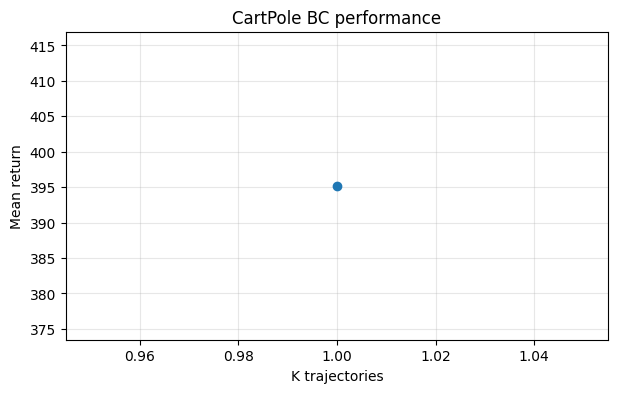

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Video, display, HTML
from pathlib import Path

results_csv = sweep_output / 'results.csv'
df = pd.read_csv(results_csv)

agg = df.groupby('size')['mean_return'].agg(['mean', 'std']).reset_index().sort_values('size')

plt.figure(figsize=(7, 4))
plt.errorbar(agg['size'], agg['mean'], yerr=agg['std'], marker='o', capsize=3)
plt.xlabel('K trajectories')
plt.ylabel('Mean return')
plt.title('CartPole BC performance')
plt.grid(alpha=0.3)
plt.show()

for size in sorted(df['size'].unique()):
    row = df[df['size'] == size].sort_values('mean_return', ascending=False).iloc[0]
    out = Path(row['output_dir'])
    videos = list((out / 'videos').glob('*.mp4'))
    display(HTML(f'<h4>Size {size} — {out}</h4>'))
    if videos:
        display(Video(str(videos[0]), embed=True, width=480))
    else:
        display(HTML('<p>No video found.</p>'))